In [2]:
!pip install streamlit scikit-learn numpy pandas matplotlib
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 84.5 MB/s eta 0:00:00



  STEP 1 · LOADING THE IRIS DATASET

  Samples : 150
  Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
  Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

species
setosa        50
versicolor    50
virginica     50

  First 5 rows:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
               5.1               3.5                1.4               0.2  setosa
               4.9               3.0                1.4               0.2  setosa
               4.7               3.2                1.3               0.2  setosa
               4.6               3.1                1.5               0.2  setosa
               5.0               3.6                1.4               0.2  setosa

  Statistical Summary:
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count             150.00            150.00             150.00            150.00
mean                5

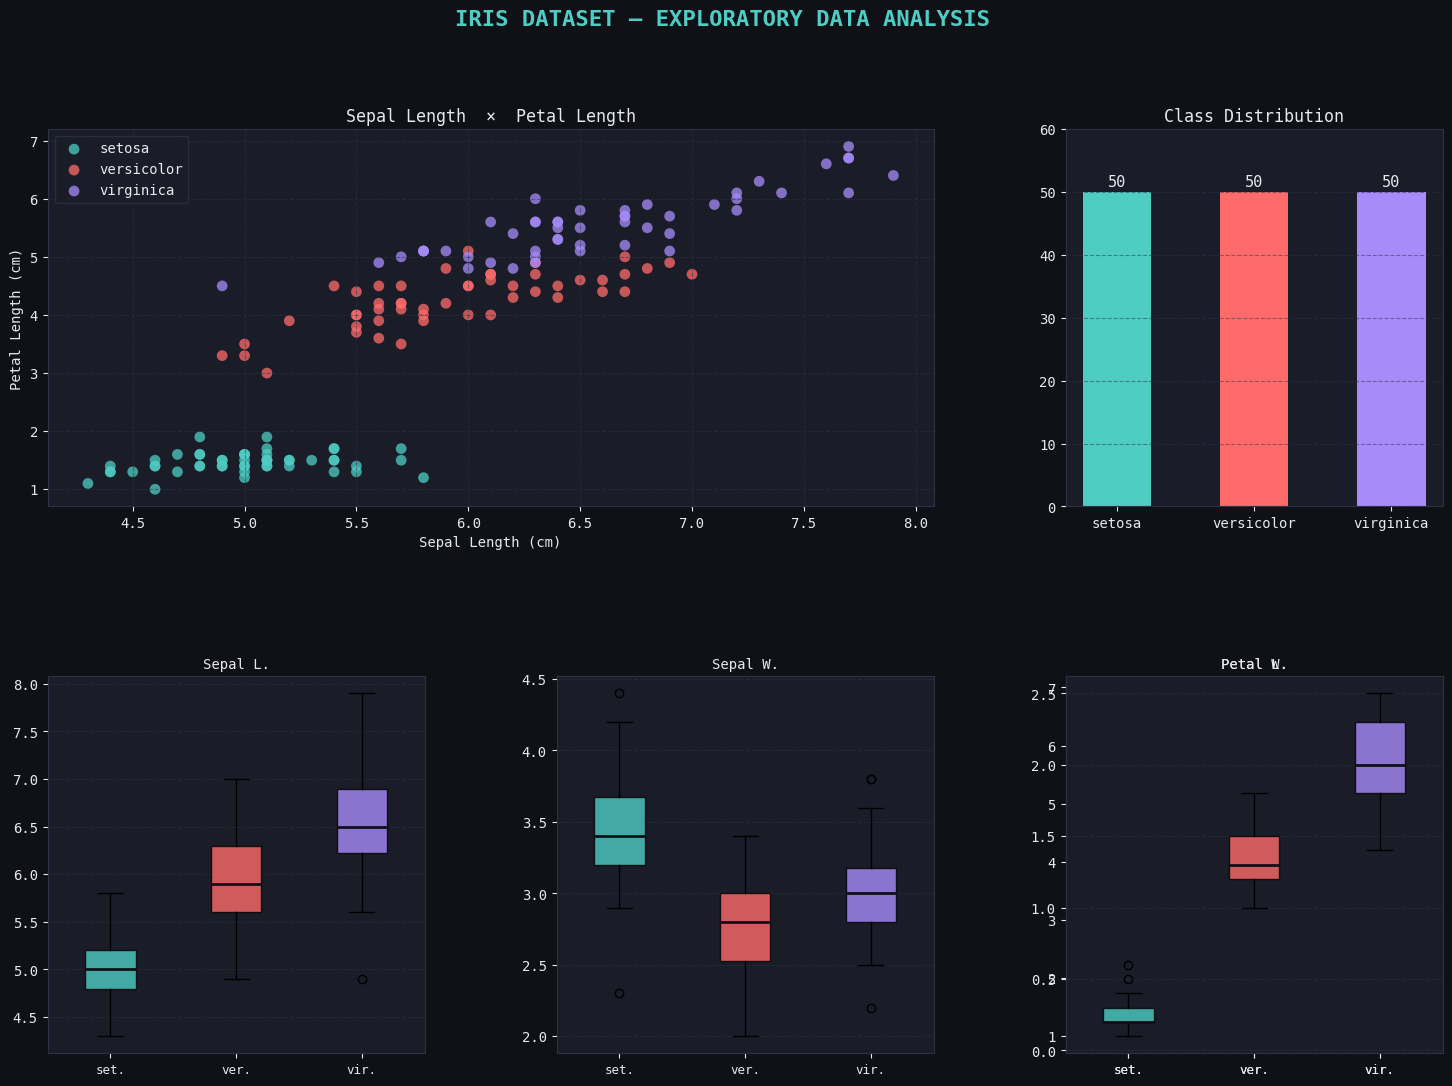

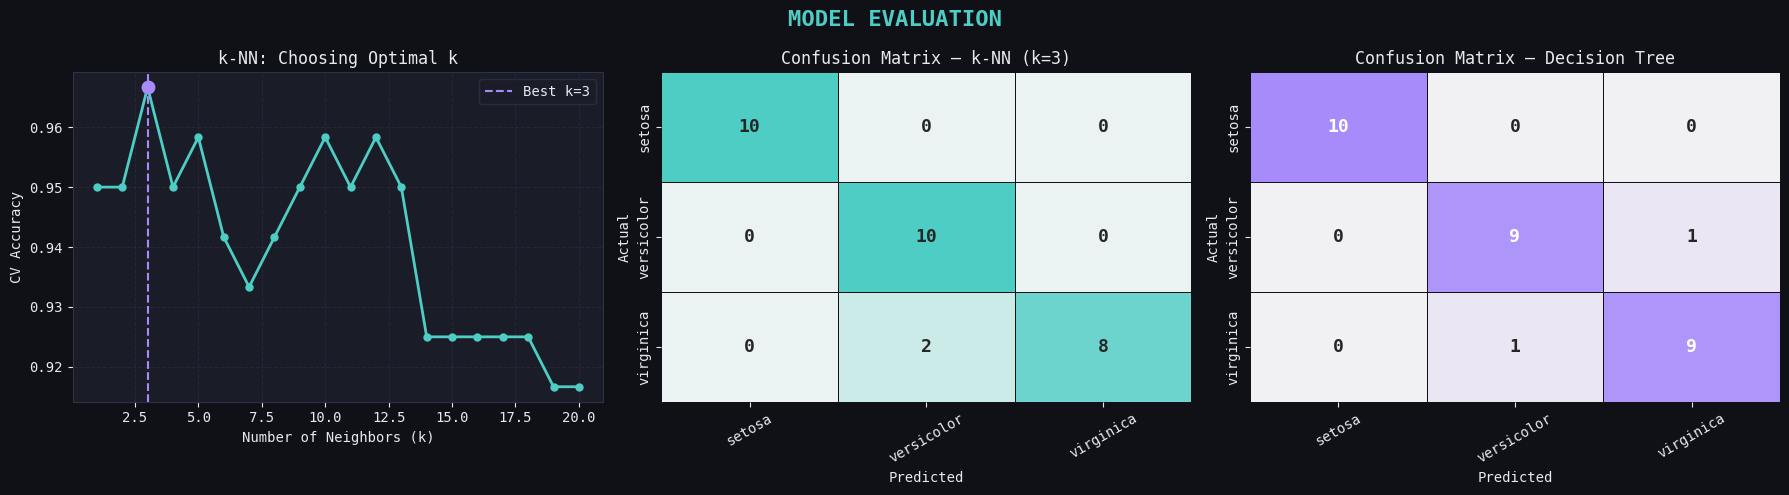

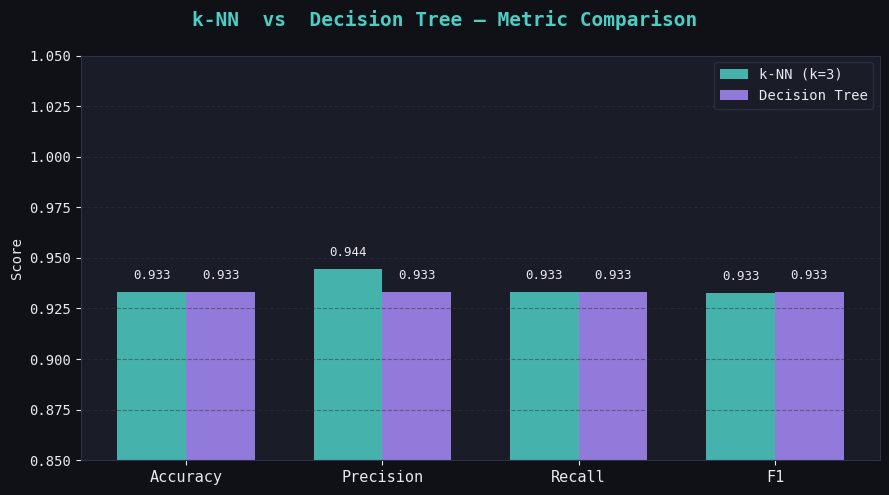

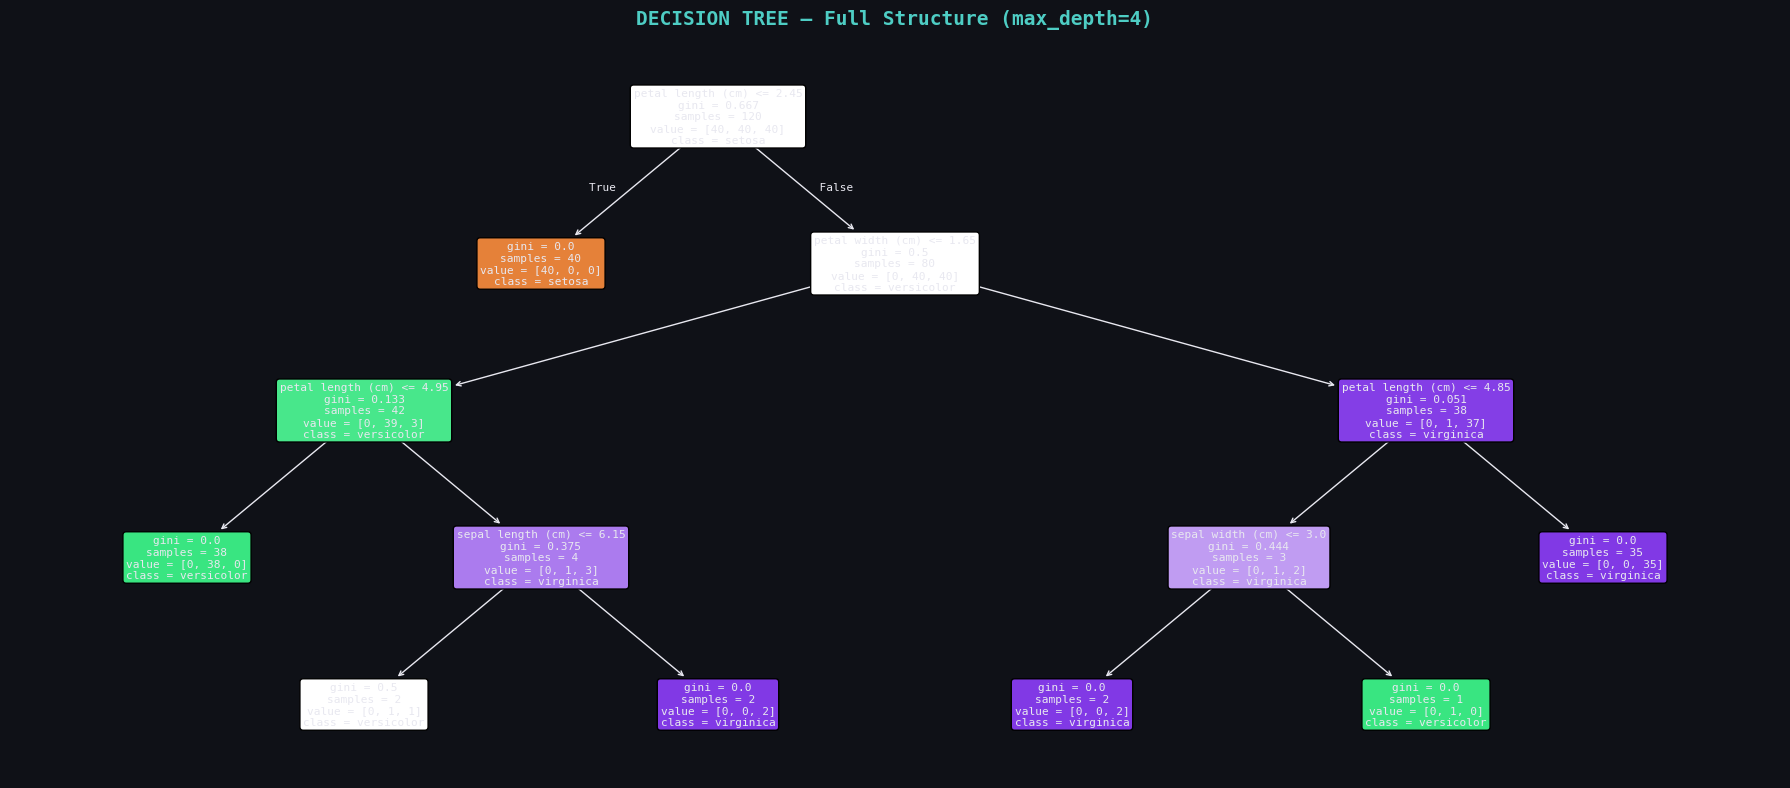

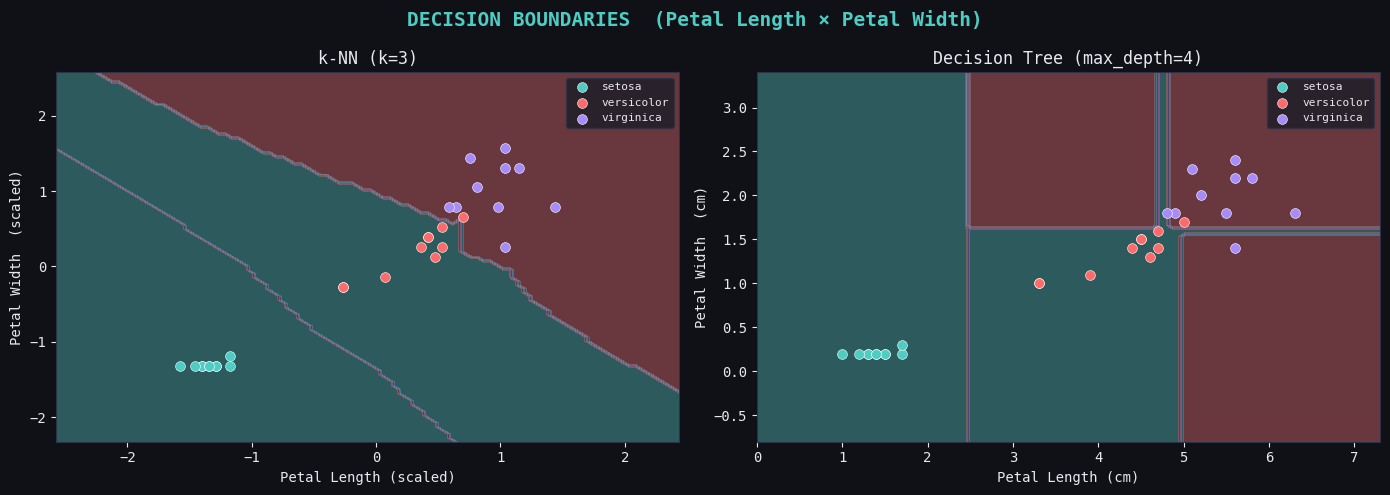


  STEP 7 · LIVE PREDICTION DEMO

  Flower                     SL    SW    PL    PW  k-NN Pred       DT Pred
  ----------------------------------------------------------------------
  Likely Setosa             5.1   3.5   1.4   0.2  setosa          setosa
  Likely Versicolor         6.0   2.7   4.2   1.3  versicolor      versicolor
  Likely Virginica          6.7   3.1   5.6   2.4  virginica       virginica

  SUMMARY

  Model              Accuracy   Precision   Recall     F1
  ─────────────────────────────────────────────────────────
  k-NN  (k=3 )        0.9333     0.9444      0.9333     0.9327
  Decision Tree      0.9333     0.9333      0.9333     0.9333

  Saved figures:
    fig1_eda.png       — EDA: scatter, class dist, box plots
    fig2_eval.png      — k-selection curve + confusion matrices
    fig3_compare.png   — Metric comparison bar chart
    fig4_tree.png      — Full decision tree structure
    fig5_boundaries.png— 2-D decision boundaries

  ✅  All done!



In [8]:
"""
╔══════════════════════════════════════════════════════════════╗
║          IRIS FLOWER CLASSIFICATION — ML PROJECT             ║
║  Algorithms : k-Nearest Neighbors  +  Decision Tree          ║
║  Metrics    : Accuracy · Precision · Recall · F1             ║
╚══════════════════════════════════════════════════════════════╝
"""

# ── 1. IMPORTS ────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import DecisionBoundaryDisplay

# ── PALETTE ───────────────────────────────────────────────────
SETOSA_C     = "#4ECDC4"   # teal
VERSICOLOR_C = "#FF6B6B"   # coral
VIRGINICA_C  = "#A78BFA"   # violet
BG           = "#0F1117"
PANEL        = "#1A1D27"
TEXT         = "#E8E8F0"
ACCENT       = "#4ECDC4"
SPECIES      = ["setosa", "versicolor", "virginica"]
PALETTE      = [SETOSA_C, VERSICOLOR_C, VIRGINICA_C]

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": PANEL,
    "axes.edgecolor": "#2E3247", "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "text.color": TEXT, "grid.color": "#2E3247",
    "grid.linestyle": "--", "grid.alpha": 0.5,
    "font.family": "monospace",
})


# ══════════════════════════════════════════════════════════════
# STEP 1 — LOAD & EXPLORE DATA
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 1 · LOADING THE IRIS DATASET")
print("="*60)

iris = load_iris()
df   = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"\n  Samples : {len(df)}")
print(f"  Features: {list(iris.feature_names)}")
print(f"  Classes : {list(iris.target_names)}\n")
print(df.groupby("species").size().to_string())
print("\n  First 5 rows:")
print(df.head().to_string(index=False))
print("\n  Statistical Summary:")
print(df.describe().round(2).to_string())


# ══════════════════════════════════════════════════════════════
# STEP 2 — TRAIN / TEST SPLIT + SCALING
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 2 · TRAIN / TEST SPLIT  (80 / 20, stratified)")
print("="*60)

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f"\n  Training samples : {len(X_train)}")
print(f"  Testing  samples : {len(X_test)}")
print(f"  Train class dist : {np.bincount(y_train)}")
print(f"  Test  class dist : {np.bincount(y_test)}")


# ══════════════════════════════════════════════════════════════
# STEP 3 — FIND OPTIMAL k FOR k-NN
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 3 · TUNING k-NN  (cross-validated k=1..20)")
print("="*60)

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_scores = {}
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, Xs_train, y_train, cv=cv, scoring="accuracy")
    k_scores[k] = scores.mean()

best_k = max(k_scores, key=k_scores.get)
print(f"\n  Best k = {best_k}  (CV accuracy = {k_scores[best_k]:.4f})")


# ══════════════════════════════════════════════════════════════
# STEP 4 — TRAIN BOTH MODELS
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 4 · TRAINING MODELS")
print("="*60)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(Xs_train, y_train)
knn_pred  = knn_model.predict(Xs_test)
print(f"\n  k-NN (k={best_k}) trained ✓")

dt_model  = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_pred   = dt_model.predict(X_test)
print(f"  Decision Tree (max_depth=4) trained ✓")


# ══════════════════════════════════════════════════════════════
# STEP 5 — EVALUATE
# ══════════════════════════════════════════════════════════════
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1  = f1_score(y_true, y_pred, average="weighted")
    print(f"\n  ── {name} ──")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {pre:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=SPECIES))
    return {"Accuracy": acc, "Precision": pre, "Recall": rec, "F1": f1}

print("\n" + "="*60)
print("  STEP 5 · EVALUATION RESULTS")
print("="*60)
knn_metrics = evaluate(f"k-NN  (k={best_k})",   y_test, knn_pred)
dt_metrics  = evaluate("Decision Tree",           y_test, dt_pred)


# ══════════════════════════════════════════════════════════════
# STEP 6 — CROSS-VALIDATION SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 6 · CROSS-VALIDATION  (5-fold)")
print("="*60)

for name, model, Xtr, Xte in [
    (f"k-NN (k={best_k})", knn_model, Xs_train, Xs_test),
    ("Decision Tree",       dt_model,  X_train,  X_test),
]:
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring="accuracy")
    print(f"\n  {name}")
    print(f"    Fold scores : {np.round(cv_scores, 4)}")
    print(f"    Mean ± Std  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ══════════════════════════════════════════════════════════════
# FIGURES
# ══════════════════════════════════════════════════════════════

# ── FIG 1 : EDA ───────────────────────────────────────────────
fig1 = plt.figure(figsize=(18, 12), facecolor=BG)
fig1.suptitle("IRIS DATASET — EXPLORATORY DATA ANALYSIS",
              fontsize=16, fontweight="bold", color=ACCENT, y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.45, wspace=0.35)

# Pairplot-style scatter (sepal vs petal)
ax_sp = fig1.add_subplot(gs[0, :2])
for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    mask = iris.target == i
    ax_sp.scatter(iris.data[mask, 0], iris.data[mask, 2],
                  c=col, label=sp, alpha=0.75, s=60, edgecolors="none")
ax_sp.set_xlabel("Sepal Length (cm)")
ax_sp.set_ylabel("Petal Length (cm)")
ax_sp.set_title("Sepal Length  ×  Petal Length", color=TEXT)
ax_sp.legend(facecolor=PANEL, edgecolor="#2E3247", labelcolor=TEXT)
ax_sp.grid(True)

# Class distribution
ax_dist = fig1.add_subplot(gs[0, 2])
counts  = [sum(iris.target == i) for i in range(3)]
bars = ax_dist.bar(SPECIES, counts, color=PALETTE, width=0.5)
for bar, cnt in zip(bars, counts):
    ax_dist.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(cnt), ha="center", va="bottom", fontsize=11, color=TEXT)
ax_dist.set_title("Class Distribution", color=TEXT)
ax_dist.set_ylim(0, 60)
ax_dist.grid(True, axis="y")

# Feature box plots
feat_names = ["Sepal L.", "Sepal W.", "Petal L.", "Petal W."]
positions  = [0, 1, 2, 3]
for col_idx, (ax_idx, feat) in enumerate(zip(positions, feat_names)):
    ax = fig1.add_subplot(gs[1, col_idx]) if col_idx < 3 else None
    if ax is None:
        # squeeze 4th box into last cell
        ax = fig1.add_subplot(gs[1, 2])
        break
    data_by_sp = [iris.data[iris.target == i, col_idx] for i in range(3)]
    bp = ax.boxplot(data_by_sp, patch_artist=True, widths=0.4,
                    medianprops=dict(color=BG, linewidth=2))
    for patch, col in zip(bp["boxes"], PALETTE):
        patch.set_facecolor(col); patch.set_alpha(0.8)
    ax.set_xticklabels(["set.", "ver.", "vir."], fontsize=9)
    ax.set_title(feat, color=TEXT, fontsize=10)
    ax.grid(True, axis="y")

# 4th box plot (Petal Width)
data_by_sp4 = [iris.data[iris.target == i, 3] for i in range(3)]
bp4 = ax.boxplot(data_by_sp4, patch_artist=True, widths=0.4,
                 medianprops=dict(color=BG, linewidth=2))
for patch, col in zip(bp4["boxes"], PALETTE):
    patch.set_facecolor(col); patch.set_alpha(0.8)
ax.set_xticklabels(["set.", "ver.", "vir."], fontsize=9)
ax.set_title("Petal W.", color=TEXT, fontsize=10)
ax.grid(True, axis="y")

plt.savefig("fig1_eda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ── FIG 2 : k SELECTION + CONFUSION MATRICES ─────────────────
fig2, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig2.suptitle("MODEL EVALUATION", fontsize=16, fontweight="bold", color=ACCENT)

# k-NN elbow curve
ks = list(k_scores.keys())
vs = list(k_scores.values())
axes[0].plot(ks, vs, color=ACCENT, linewidth=2, marker="o", markersize=5)
axes[0].axvline(best_k, color=VIRGINICA_C, linestyle="--", linewidth=1.5,
                label=f"Best k={best_k}")
axes[0].scatter([best_k], [k_scores[best_k]], color=VIRGINICA_C, s=80, zorder=5)
axes[0].set_title("k-NN: Choosing Optimal k", color=TEXT)
axes[0].set_xlabel("Number of Neighbors (k)")
axes[0].set_ylabel("CV Accuracy")
axes[0].legend(facecolor=PANEL, edgecolor="#2E3247", labelcolor=TEXT)
axes[0].grid(True)
axes[0].set_facecolor(PANEL)

# Confusion matrix — k-NN
cm_knn = confusion_matrix(y_test, knn_pred)
sns.heatmap(cm_knn, annot=True, fmt="d", ax=axes[1],
            xticklabels=SPECIES, yticklabels=SPECIES,
            cmap=sns.light_palette(ACCENT, as_cmap=True),
            linewidths=0.5, linecolor=BG, cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
axes[1].set_title(f"Confusion Matrix — k-NN (k={best_k})", color=TEXT)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_facecolor(PANEL)

# Confusion matrix — Decision Tree
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt="d", ax=axes[2],
            xticklabels=SPECIES, yticklabels=SPECIES,
            cmap=sns.light_palette(VIRGINICA_C, as_cmap=True),
            linewidths=0.5, linecolor=BG, cbar=False,
            annot_kws={"size": 13, "weight": "bold"})
axes[2].set_title("Confusion Matrix — Decision Tree", color=TEXT)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
axes[2].tick_params(axis="x", rotation=30)
axes[2].set_facecolor(PANEL)

plt.tight_layout()
plt.savefig("fig2_eda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ── FIG 3 : METRICS COMPARISON ────────────────────────────────
fig3, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
fig3.suptitle("k-NN  vs  Decision Tree — Metric Comparison",
              fontsize=14, fontweight="bold", color=ACCENT)

metrics = ["Accuracy", "Precision", "Recall", "F1"]
knn_v   = [knn_metrics[m] for m in metrics]
dt_v    = [dt_metrics[m]  for m in metrics]

x   = np.arange(len(metrics))
w   = 0.35
b1  = ax.bar(x - w/2, knn_v, w, color=ACCENT,       alpha=0.85, label=f"k-NN (k={best_k})")
b2  = ax.bar(x + w/2, dt_v,  w, color=VIRGINICA_C,  alpha=0.85, label="Decision Tree")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, color=TEXT)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel("Score")
ax.legend(facecolor=PANEL, edgecolor="#2E3247", labelcolor=TEXT)
ax.grid(True, axis="y")
ax.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig("fig3_eda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ── FIG 4 : DECISION TREE VISUALISATION ──────────────────────
fig4, ax4 = plt.subplots(figsize=(18, 8), facecolor=BG)
fig4.suptitle("DECISION TREE — Full Structure (max_depth=4)",
              fontsize=14, fontweight="bold", color=ACCENT)
plot_tree(
    dt_model,
    feature_names=iris.feature_names,
    class_names=SPECIES,
    filled=True, rounded=True, ax=ax4,
    fontsize=8,
    impurity=True,
)
# Recolour tree nodes
for patch in ax4.patches:
    patch.set_edgecolor("#2E3247")
ax4.set_facecolor(PANEL)
plt.tight_layout()
plt.savefig("fig4_eda.png", dpi=150, bbox_inches="tight",)
plt.show()
plt.close()


# ── FIG 5 : DECISION BOUNDARIES (2-D) ────────────────────────
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)
fig5.suptitle("DECISION BOUNDARIES  (Petal Length × Petal Width)",
              fontsize=14, fontweight="bold", color=ACCENT)

feat_idx = [2, 3]   # petal length, petal width
Xb_train = X_train[:, feat_idx]
Xb_test  = X_test[:,  feat_idx]

scaler2d = StandardScaler()

# k-NN boundary
knn_b = KNeighborsClassifier(n_neighbors=best_k)
knn_b.fit(scaler2d.fit_transform(Xb_train), y_train)

Xb_test_scaled = scaler2d.transform(Xb_test)
DecisionBoundaryDisplay.from_estimator(
    knn_b,
    Xb_test_scaled,
    ax=axes5[0], alpha=0.35,
    response_method="predict",
    colors=[SETOSA_C, VERSICOLOR_C, VIRGINICA_C],
)
for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    mask = y_test == i
    axes5[0].scatter(Xb_test_scaled[mask, 0],
                     Xb_test_scaled[mask, 1],
                     c=col, label=sp, edgecolors="white", s=50, linewidths=0.4)
axes5[0].set_title(f"k-NN (k={best_k})", color=TEXT)
axes5[0].set_xlabel("Petal Length (scaled)")
axes5[0].set_ylabel("Petal Width  (scaled)")
axes5[0].legend(facecolor=PANEL, edgecolor="#2E3247", labelcolor=TEXT, fontsize=8)
axes5[0].set_facecolor(PANEL)

# DT boundary
dt_b = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_b.fit(Xb_train, y_train)

DecisionBoundaryDisplay.from_estimator(
    dt_b, Xb_test, ax=axes5[1], alpha=0.35,
    response_method="predict",
    colors=[SETOSA_C, VERSICOLOR_C, VIRGINICA_C],
)
for i, (sp, col) in enumerate(zip(SPECIES, PALETTE)):
    mask = y_test == i
    axes5[1].scatter(Xb_test[mask, 0], Xb_test[mask, 1],
                     c=col, label=sp, edgecolors="white", s=50, linewidths=0.4)
axes5[1].set_title("Decision Tree (max_depth=4)", color=TEXT)
axes5[1].set_xlabel("Petal Length (cm)")
axes5[1].set_ylabel("Petal Width  (cm)")
axes5[1].legend(facecolor=PANEL, edgecolor="#2E3247", labelcolor=TEXT, fontsize=8)
axes5[1].set_facecolor(PANEL)

plt.tight_layout()
plt.savefig("fig5_eda.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()


# ══════════════════════════════════════════════════════════════
# STEP 7 — SAMPLE PREDICTION DEMO
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  STEP 7 · LIVE PREDICTION DEMO")
print("="*60)

sample_flowers = {
    "Likely Setosa"    : [5.1, 3.5, 1.4, 0.2],
    "Likely Versicolor": [6.0, 2.7, 4.2, 1.3],
    "Likely Virginica" : [6.7, 3.1, 5.6, 2.4],
}

print(f"\n  {'Flower':<22}  {'SL':>5} {'SW':>5} {'PL':>5} {'PW':>5}  "
      f"{'k-NN Pred':<15} {'DT Pred'}")
print("  " + "-"*70)

for name, feat in sample_flowers.items():
    f_arr      = np.array(feat).reshape(1, -1)
    f_scaled   = scaler.transform(f_arr)
    knn_p = SPECIES[knn_model.predict(f_scaled)[0]]
    dt_p  = SPECIES[dt_model.predict(f_arr)[0]]
    print(f"  {name:<22}  {feat[0]:>5} {feat[1]:>5} {feat[2]:>5} {feat[3]:>5}  "
          f"{knn_p:<15} {dt_p}")


# ══════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  SUMMARY")
print("="*60)
print(f"""
  Model              Accuracy   Precision   Recall     F1
  ─────────────────────────────────────────────────────────
  k-NN  (k={best_k:<2})        {knn_metrics['Accuracy']:.4f}     {knn_metrics['Precision']:.4f}      {knn_metrics['Recall']:.4f}     {knn_metrics['F1']:.4f}
  Decision Tree      {dt_metrics['Accuracy']:.4f}     {dt_metrics['Precision']:.4f}      {dt_metrics['Recall']:.4f}     {dt_metrics['F1']:.4f}

  Saved figures:
    fig1_eda.png       — EDA: scatter, class dist, box plots
    fig2_eval.png      — k-selection curve + confusion matrices
    fig3_compare.png   — Metric comparison bar chart
    fig4_tree.png      — Full decision tree structure
    fig5_boundaries.png— 2-D decision boundaries
""")
print("  ✅  All done!\n")


In [15]:
%%writefile app.py

# Paste your entire Streamlit app code below this line
import streamlit as st
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Train model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Streamlit UI
st.title("🌸 Iris Flower Classification")
st.write("Predict the species of an Iris flower based on flower measurements.")

sepal_length = st.number_input("Sepal Length (cm)", value=5.1)
sepal_width = st.number_input("Sepal Width (cm)", value=3.5)
petal_length = st.number_input("Petal Length (cm)", value=1.4)
petal_width = st.number_input("Petal Width (cm)", value=0.2)

if st.button("Predict"):
    prediction = model.predict([[sepal_length, sepal_width, petal_length, petal_width]])
    st.success(f"Predicted Species: **{iris.target_names[prediction[0]].capitalize()}**")

Writing app.py


In [19]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
!pip install -q streamlit
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 7s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [25]:
!ls

app.py	      fig2_eda.png  fig4_eda.png  sample_data
fig1_eda.png  fig3_eda.png  fig5_eda.png


In [26]:
!streamlit run app.py &>/content/logs.txt &

In [30]:
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦your url is: https://gentle-rules-yell.loca.lt
^C


In [31]:
!curl https://loca.lt/mytunnelpassword

34.75.161.147